In [1]:
import os
import base64
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

OUT_DIR = "level4/output"
os.makedirs(OUT_DIR, exist_ok=True)

print("pandas", pd.__version__, "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)

pandas 2.2.3 | matplotlib 3.10.0 | seaborn 0.13.2


In [2]:
CANDIDATE_PATHS = [
    "level2/output/trains_enriched.csv",
    "trains_enriched.csv",
    "level1/output/trains_cleaned.csv",
    "trains_cleaned.csv",
    "Railway_info.csv",
    "data/raw/Railway_info.csv",
]

def load_dataset():
    """Return (dataframe, source_path). Falls back to a Colab upload widget."""
    for path in CANDIDATE_PATHS:
        if os.path.exists(path):
            print(f"Loading dataset from: {path}")
            return pd.read_csv(path), path
    try:  # Google Colab upload fallback
        from google.colab import files
        print("Dataset not found in this session — please upload your CSV:")
        uploaded = files.upload()
        name = next(iter(uploaded))
        return pd.read_csv(name), name
    except ImportError:
        raise FileNotFoundError(
            "Could not locate the dataset CSV. Upload it (Colab: folder icon) and re-run."
        )

df, source_path = load_dataset()

def find_column(frame, *patterns):
    """First column whose lower-cased name contains any of the patterns."""
    for pattern in patterns:
        for col in frame.columns:
            if pattern in col.lower():
                return col
    return None

train_col  = find_column(df, "train no", "train_no", "train id", "train code", "train") or df.columns[0]
source_col = find_column(df, "source", "origin") or find_column(df, "from")
dest_col   = find_column(df, "destination") or find_column(df, "to")
day_col    = find_column(df, "day") or "days"

DAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

def normalize_day(value):
    v = str(value).strip().capitalize()
    for day in DAYS:
        if v.startswith(day):
            return day
    return v

_clean = df[day_col].fillna("UNKNOWN").astype(str).str.strip().str.capitalize()
n_dirty = int((~_clean.isin(DAYS)).sum())
if n_dirty:
    df[day_col] = _clean.apply(normalize_day)
    print(f"Repaired {n_dirty:,} corrupted day value(s).")

def categorize_day(day):
    if day in {"Saturday", "Sunday"}:
        return "Weekend"
    if day in {"Monday", "Tuesday", "Wednesday", "Thursday", "Friday"}:
        return "Weekday"
    return "Unknown"

if "Day_Category" not in df.columns:
    df["Day_Category"] = df[day_col].apply(categorize_day)

print(f"Rows: {len(df):,} | Columns: {df.shape[1]}")

Loading dataset from: Railway_info.csv
Repaired 1,153 corrupted day value(s).
Rows: 11,113 | Columns: 6


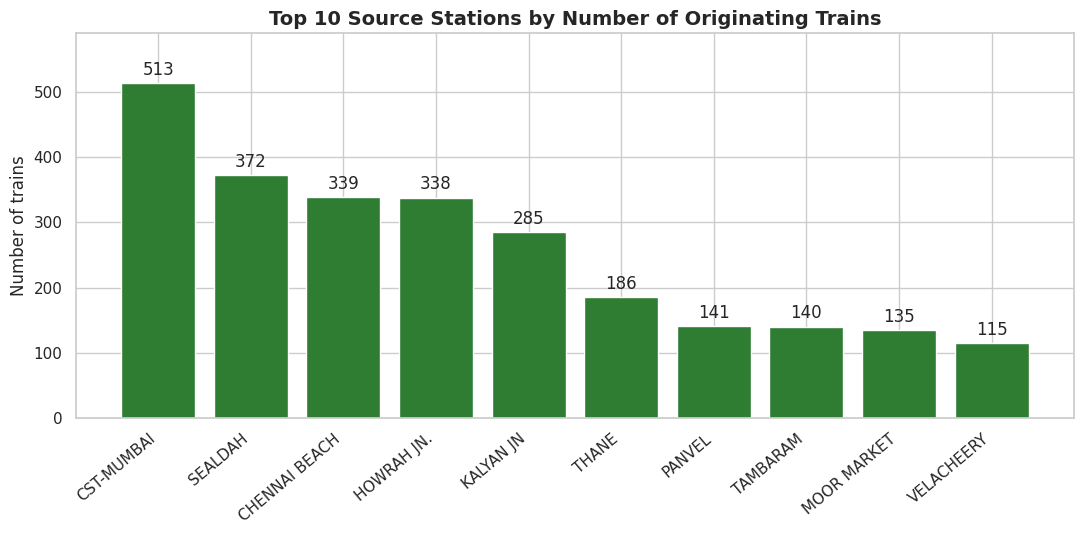

Source_Station_Name
CST-MUMBAI       513
SEALDAH          372
CHENNAI BEACH    339
HOWRAH JN.       338
KALYAN JN        285
THANE            186
PANVEL           141
TAMBARAM         140
MOOR MARKET      135
VELACHEERY       115
Name: count, dtype: int64


In [3]:
src_counts = df[source_col].value_counts()
top_src = src_counts.head(10)

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar(range(len(top_src)), top_src.values, color="#2e7d32")
ax.bar_label(bars, fmt="{:,.0f}", padding=3)
ax.set_xticks(range(len(top_src)))
ax.set_xticklabels(top_src.index, rotation=40, ha="right")
ax.set_title("Top 10 Source Stations by Number of Originating Trains",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Number of trains")
ax.set_ylim(0, top_src.max() * 1.15)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4_trains_per_station.png", dpi=150)
plt.show()

print(top_src)

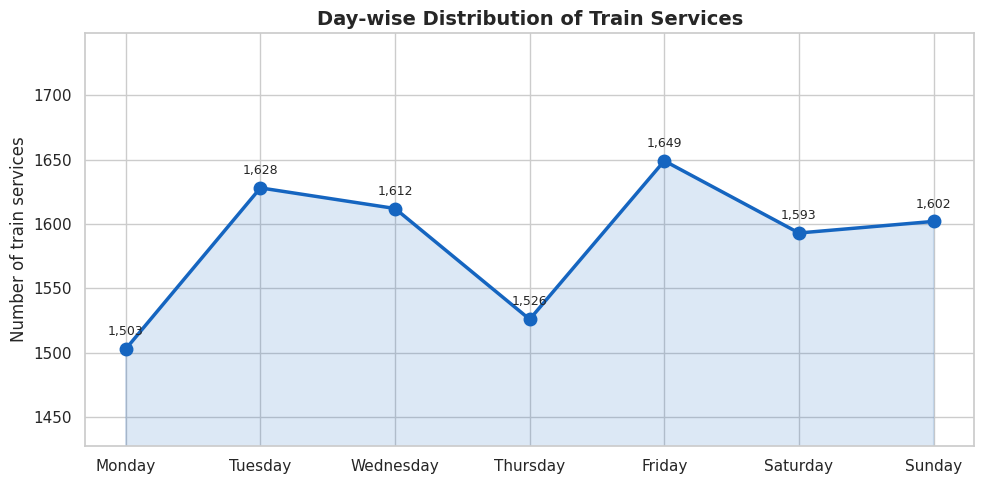

Busiest: Friday (1,649) | Quietest: Monday (1,503)


In [4]:
weekly = df[day_col].value_counts().reindex(DAYS)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(DAYS, weekly.values, marker="o", linewidth=2.5, markersize=9, color="#1565c0")
ax.fill_between(range(7), weekly.values, alpha=0.15, color="#1565c0")
for x, y in zip(range(7), weekly.values):
    ax.annotate(f"{y:,}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha="center", fontsize=9)
ax.set_title("Day-wise Distribution of Train Services", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of train services")
ax.set_ylim(weekly.min() * 0.95, weekly.max() * 1.06)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4_weekly_line.png", dpi=150)
plt.show()

print(f"Busiest: {weekly.idxmax()} ({weekly.max():,}) | Quietest: {weekly.idxmin()} ({weekly.min():,})")

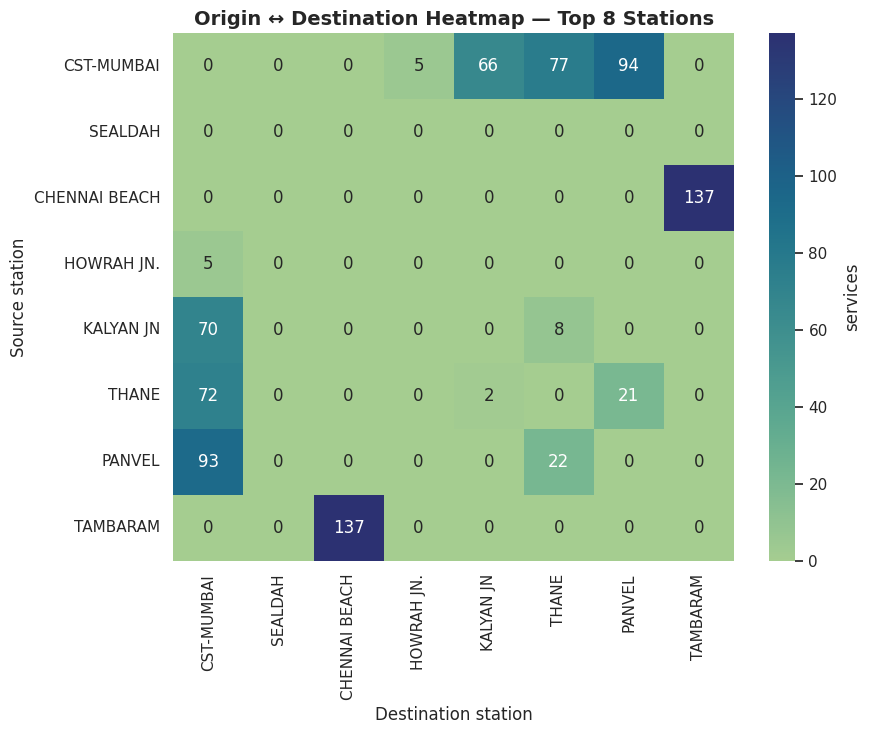

In [5]:
top8 = list(src_counts.head(8).index)
od = (
    df[df[source_col].isin(top8) & df[dest_col].isin(top8)]
    .groupby([source_col, dest_col]).size()
    .unstack(fill_value=0)
    .reindex(index=top8, columns=top8, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(od, annot=True, fmt="d", cmap="crest", cbar_kws={"label": "services"}, ax=ax)
ax.set_title("Origin ↔ Destination Heatmap — Top 8 Stations", fontsize=14, fontweight="bold")
ax.set_xlabel("Destination station")
ax.set_ylabel("Source station")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4_od_heatmap.png", dpi=150)
plt.show()

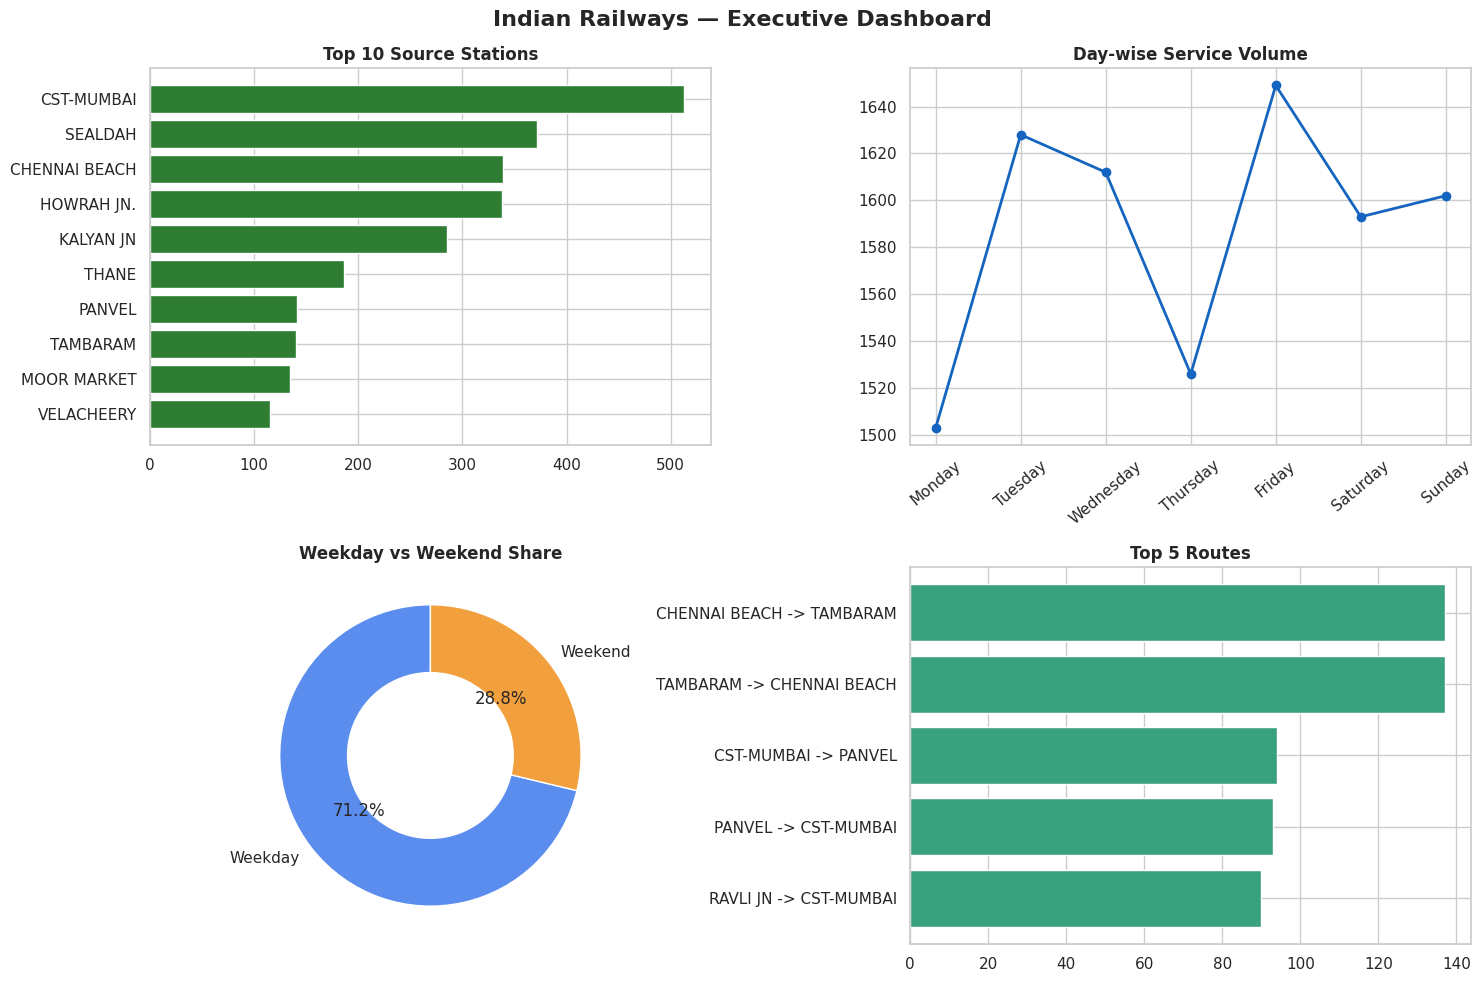

In [6]:
top5_routes = (
    df.groupby([source_col, dest_col]).size()
      .sort_values(ascending=False).head(5)
)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].barh(top_src.index[::-1], top_src.values[::-1], color="#2e7d32")
axes[0, 0].set_title("Top 10 Source Stations", fontweight="bold")

axes[0, 1].plot(DAYS, weekly.values, marker="o", linewidth=2, color="#1565c0")
axes[0, 1].tick_params(axis="x", rotation=40)
axes[0, 1].set_title("Day-wise Service Volume", fontweight="bold")

cat = df["Day_Category"].value_counts()
axes[1, 0].pie(cat.values, labels=cat.index, autopct="%1.1f%%",
               colors=["#5b8def", "#f2a03d"], wedgeprops={"width": 0.45}, startangle=90)
axes[1, 0].set_title("Weekday vs Weekend Share", fontweight="bold")

rlabels = [f"{s} -> {d}" for s, d in top5_routes.index]
axes[1, 1].barh(rlabels[::-1], top5_routes.values[::-1], color="#3aa17e")
axes[1, 1].set_title("Top 5 Routes", fontweight="bold")

fig.suptitle("Indian Railways — Executive Dashboard", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/fig4_executive_dashboard.png", dpi=150)
plt.show()

In [7]:
corridors = (
    df.apply(lambda r: " <-> ".join(sorted([r[source_col], r[dest_col]])), axis=1)
      .value_counts()
)
day_index  = pd.Series(range(7), index=DAYS)
is_weekend = pd.Series([0, 0, 0, 0, 0, 1, 1], index=DAYS)
r_ordinal  = weekly.corr(day_index)
r_weekend  = weekly.corr(is_weekend)
weekend_share = weekly[DAYS[5:]].sum() / weekly.sum() * 100
hub_share  = src_counts.head(10).sum() / len(df) * 100

# Data-quality stats, recomputed from the raw feed when it is available
n_repaired = None
for p in ["data/raw/Railway_info.csv", "Railway_info.csv"]:
    if os.path.exists(p):
        raw = pd.read_csv(p)
        rc = find_column(raw, "day") or "days"
        n_repaired = int((~raw[rc].fillna("UNKNOWN").astype(str).str.strip()
                          .str.capitalize().isin(DAYS)).sum())
        break

M = dict(
    rows=len(df),
    trains=int(df[train_col].nunique()),
    n_src=int(df[source_col].nunique()),
    n_dst=int(df[dest_col].nunique()),
    missing_now=int(df.isnull().sum().sum()),
    repaired=n_repaired,
    top_hub=src_counts.index[0], top_hub_n=int(src_counts.iloc[0]),
    top3_hubs=", ".join(src_counts.head(3).index),
    hub_share=round(float(hub_share), 1),
    top_route=f"{top5_routes.index[0][0]} -> {top5_routes.index[0][1]}",
    top_route_n=int(top5_routes.iloc[0]),
    top_corridor=corridors.index[0], top_corridor_n=int(corridors.iloc[0]),
    busiest=weekly.idxmax(), busiest_n=int(weekly.max()),
    quietest=weekly.idxmin(), quietest_n=int(weekly.min()),
    weekend_share=round(float(weekend_share), 1),
    r_ordinal=round(float(r_ordinal), 3), r_weekend=round(float(r_weekend), 3),
)
for k, v in M.items():
    print(f"{k:14} : {v}")

rows           : 11113
trains         : 11113
n_src          : 921
n_dst          : 924
missing_now    : 0
repaired       : 1153
top_hub        : CST-MUMBAI
top_hub_n      : 513
top3_hubs      : CST-MUMBAI, SEALDAH, CHENNAI BEACH
hub_share      : 23.1
top_route      : CHENNAI BEACH -> TAMBARAM
top_route_n    : 137
top_corridor   : CHENNAI BEACH <-> TAMBARAM
top_corridor_n : 274
busiest        : Friday
busiest_n      : 1649
quietest       : Monday
quietest_n     : 1503
weekend_share  : 28.8
r_ordinal      : 0.381
r_weekend      : 0.127


In [8]:
repaired_line = (f"{M['repaired']:,} corrupted day tokens repaired"
                 if M['repaired'] is not None else "corrupted day tokens repaired (Level 2)")

md_report = f"""# 🚆 Indian Railways — Train Operations Analytics Report

*Compiled from the four-level data-engineering pipeline (Levels 1–4).*

## Executive Summary

- The network covers **{M['trains']:,} train services** across **{M['n_src']:,} source** and
  **{M['n_dst']:,} destination stations** ({M['rows']:,} weekly records).
- Demand is stable across the week (**{M['quietest_n']:,}–{M['busiest_n']:,} services/day**);
  **{M['busiest']}** peaks and **{M['quietest']}** is the quietest day.
- Operations are hub-driven: **{M['top3_hubs']}** lead, and the top-10 hubs carry
  **{M['hub_share']}%** of services. The busiest corridor is **{M['top_corridor']}**
  ({M['top_corridor_n']:,} services).
- Data quality is production-grade after the pipeline: **{M['missing_now']} missing values**,
  {repaired_line}, station names standardized.

## 1 · Data Overview & Quality (Level 1–2)

| Metric | Value |
|--------|-------|
| Weekly records | {M['rows']:,} |
| Missing values after cleaning | {M['missing_now']} |
| Corrupted day tokens repaired | {M['repaired'] if M['repaired'] is not None else 'see Level 2'} |
| Weekend / Weekday share | {M['weekend_share']}% / {round(100 - M['weekend_share'], 1)}% |

## 2 · Network & Station Patterns (Level 2 + 4.1)

![Top stations](fig4_trains_per_station.png)

- **{M['top_hub']}** is the largest origin hub ({M['top_hub_n']:,} trains).
- Busiest single route: **{M['top_route']}** ({M['top_route_n']:,} services).

## 3 · Weekly Rhythm (Level 3 + 4.1)

![Weekly line](fig4_weekly_line.png)

- Correlation of volume with day position: **r={M['r_ordinal']:+.3f}** (weak);
  weekend effect **r={M['r_weekend']:+.3f}** (negligible) — demand is evenly spread.

![OD heatmap](fig4_od_heatmap.png)

## 4 · Executive Dashboard (4.1)

![Dashboard](fig4_executive_dashboard.png)

## 5 · Recommendations

1. Keep reserve capacity for **{M['busiest']}** peaks; schedule maintenance on **{M['quietest']}**.
2. Protect weekend frequency — weekends carry **{M['weekend_share']}%** of weekly volume.
3. Prioritize infrastructure & punctuality monitoring at **{M['top3_hubs']}**.
4. Optimize at route/corridor level — calendar day explains little of the variance.

---
*Generated automatically by `level4/level4_visualization_and_reporting.ipynb`.*
"""

with open(f"{OUT_DIR}/final_report.md", "w") as fh:
    fh.write(md_report)
print(f"Saved {OUT_DIR}/final_report.md")
print(md_report[:600], "...")

💾 Saved level4/output/final_report.md
# 🚆 Indian Railways — Train Operations Analytics Report

*Compiled from the four-level data-engineering pipeline (Levels 1–4).*

## Executive Summary

- The network covers **11,113 train services** across **921 source** and
  **924 destination stations** (11,113 weekly records).
- Demand is stable across the week (**1,503–1,649 services/day**);
  **Friday** peaks and **Monday** is the quietest day.
- Operations are hub-driven: **CST-MUMBAI, SEALDAH, CHENNAI BEACH** lead, and the top-10 hubs carry
  **23.1%** of services. The busiest corridor is **CHENNAI BEACH <-> TAMBARAM**
  (274 services).
 ...


In [9]:
def b64(name):
    with open(f"{OUT_DIR}/{name}", "rb") as fh:
        return base64.b64encode(fh.read()).decode()

IMG = {n: b64(n) for n in ["fig4_executive_dashboard.png", "fig4_trains_per_station.png",
                           "fig4_weekly_line.png", "fig4_od_heatmap.png"]}

CSS = (
    "body{font-family:'Segoe UI',Arial,sans-serif;margin:0;background:#f4f6f8;color:#22303c}"
    ".wrap{max-width:900px;margin:0 auto;background:#fff;padding:40px 48px;box-shadow:0 2px 12px rgba(0,0,0,.08)}"
    "h1{color:#0d47a1;border-bottom:4px solid #0d47a1;padding-bottom:12px}"
    "h2{color:#1565c0;margin-top:36px}"
    "table{border-collapse:collapse;width:100%;margin:16px 0}"
    "td,th{border:1px solid #cfd8dc;padding:8px 12px;text-align:left;font-size:14px}"
    "th{background:#e3f2fd}"
    "img{width:100%;border:1px solid #e0e0e0;border-radius:6px;margin:12px 0}"
    ".kpi{display:flex;gap:16px;flex-wrap:wrap;margin:20px 0}"
    ".kpi div{flex:1;min-width:150px;background:#e8f0fe;border-radius:8px;padding:14px;text-align:center}"
    ".kpi b{display:block;font-size:22px;color:#0d47a1}"
    "li{margin:6px 0}"
)

html = f"""<!doctype html><html><head><meta charset="utf-8">
<title>Indian Railways — Analytics Report</title><style>{CSS}</style></head><body><div class="wrap">
<h1> Indian Railways — Train Operations Analytics Report</h1>
<p><i>Compiled automatically by the Level 4 notebook of the railway data-engineering pipeline.</i></p>

<div class="kpi">
<div><b>{M['rows']:,}</b>weekly records</div>
<div><b>{M['trains']:,}</b>train services</div>
<div><b>{M['n_src']:,}</b>source stations</div>
<div><b>{M['top_hub']}</b>largest hub</div>
<div><b>{M['weekend_share']}%</b>weekend share</div>
</div>

<h2>Executive Summary</h2>
<ul>
<li>Demand is stable across the week ({M['quietest_n']:,}–{M['busiest_n']:,} services/day); <b>{M['busiest']}</b> peaks, <b>{M['quietest']}</b> is quietest.</li>
<li>Hub-driven network: top-10 hubs carry <b>{M['hub_share']}%</b> of services; busiest corridor <b>{M['top_corridor']}</b> ({M['top_corridor_n']:,} services).</li>
<li>Production-grade data quality: <b>{M['missing_now']}</b> missing values after the cleaning pipeline.</li>
</ul>

<h2>Executive Dashboard</h2>
<img src="data:image/png;base64,{IMG['fig4_executive_dashboard.png']}" alt="dashboard">

<h2>Trains per Station</h2>
<img src="data:image/png;base64,{IMG['fig4_trains_per_station.png']}" alt="bar chart">

<h2>Day-wise Distribution</h2>
<img src="data:image/png;base64,{IMG['fig4_weekly_line.png']}" alt="line chart">
<p>Correlation of volume with day position r={M['r_ordinal']:+.3f} (weak); weekend effect r={M['r_weekend']:+.3f} (negligible).</p>

<h2>Origin ↔ Destination Flows</h2>
<img src="data:image/png;base64,{IMG['fig4_od_heatmap.png']}" alt="heatmap">

<h2>Recommendations</h2>
<ol>
<li>Keep reserve capacity for <b>{M['busiest']}</b> peaks; schedule maintenance on <b>{M['quietest']}</b>.</li>
<li>Protect weekend frequency — weekends carry {M['weekend_share']}% of weekly volume.</li>
<li>Prioritize infrastructure & punctuality monitoring at {M['top3_hubs']}.</li>
<li>Optimize at route/corridor level — calendar day explains little of the variance.</li>
</ol>

<p style="margin-top:32px;color:#78909c;font-size:12px">Railway Data Engineering Internship · Levels 1–4 · generated {pd.Timestamp.today().strftime('%d %b %Y')}</p>
</div></body></html>"""

with open(f"{OUT_DIR}/final_report.html", "w") as fh:
    fh.write(html)

print(f"Saved {OUT_DIR}/final_report.html ({os.path.getsize(f'{OUT_DIR}/final_report.html') // 1024} KB)")
print("\nLevel 4 artifacts:")
for f in sorted(os.listdir(OUT_DIR)):
    print("   -", f)

try:  # auto-download the HTML report when running in Colab
    from google.colab import files
    files.download(f"{OUT_DIR}/final_report.html")
except ImportError:
    pass

Saved level4/output/final_report.html (663 KB)

Level 4 artifacts:
   - fig4_executive_dashboard.png
   - fig4_od_heatmap.png
   - fig4_trains_per_station.png
   - fig4_weekly_line.png
   - final_report.html
   - final_report.md


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>